In [1]:
import pandas as pd
import math
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
import tensorflow as tf
import keras.backend as K
from tensorflow import keras
from tensorflow.keras import Sequential, layers, callbacks
from keras.callbacks import EarlyStopping
import keras_tuner as kt
from tensorflow.keras.layers import Dropout
from keras_tuner.tuners import RandomSearch
from keras_tuner.engine.hyperparameters import HyperParameters
#sns.set(font_scale=1.5, style="whitegrid")
plt.style.use('seaborn')

2025-03-21 02:20:57.047654: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-21 02:20:57.070474: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-21 02:20:57.077468: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-21 02:20:57.094893: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-21 02:20:58.374960: W tensorflow/compiler/tf2

In [2]:
# Set random seed for reproducibility
np.random.seed(1705)
tf.random.set_seed(1705)

In [ ]:
# Load the dataset
file = 'data.csv'
Data = pd.read_csv(file, parse_dates = ['time'], index_col = 'time')
Data=Data.reset_index()
# ramener time au format datetime
Data['time'] = pd.to_datetime(Data['time'])
Data = Data.drop('Unnamed: 0', axis = 1)
Data= Data.set_index('time')
Data.head()

# Chargement de la base de données synthétiques

In [ ]:
## chargement de la data initiale
dataset = pd.read_csv("/home/oem/Documents/these/code/test_timGAN3/generated_data.csv", index_col="time", parse_dates=["time"])
print(dataset.shape)

In [ ]:
## chargement de la data initiale
dataset = pd.read_csv("Data.csv", index_col="time", parse_dates=["time"])
# ordonner le dataset
dataset = dataset.sort_index()
# remplacer les données manquantes par 0
dataset= dataset.fillna(0)
print(dataset.shape)  

In [ ]:
## chargement de la data initiale
dataset = pd.read_csv("/home/oem/Documents/these/code/Test_timeGAN/data/Dataset.csv", index_col="time", parse_dates=["time"])
print(dataset.shape)

In [ ]:
data = dataset.loc['2020-06-01 ':'2020-08-31 ',:] 
data

In [ ]:
# ordonner le dataset
data = data.sort_index()
# remplacer les données manquantes par 0
data= data.fillna(0)

In [ ]:
data.to_csv('data.csv', header=True, index=True)

In [3]:
## chargement de l'echantillon
file = 'data.csv'
data= pd.read_csv(file, parse_dates = ['time'], index_col = 'time')
data

,longitude,latitude,Temp_2m,SST,Total_precip,level,Rel_hum,Spec_hum,U_wind,V_wind
time,,,,,,,,,,
2020-06-01 00:00:00,-20.00,17.00,294.49365,296.05640,0.000000,100,51.933450,0.000003,13.262855,12.979732
2020-06-01 00:00:00,-6.75,7.00,298.11673,0.00000,0.000000,700,63.556664,0.006822,0.164469,0.276195
2020-06-01 00:00:00,-3.25,15.25,305.32526,0.00000,0.000000,600,88.835190,0.006115,-3.804608,3.357335
2020-06-01 00:00:00,7.25,6.50,299.05032,0.00000,0.000000,200,81.059395,0.000067,6.105811,11.218180
2020-06-01 00:00:00,-11.00,13.75,303.65753,0.00000,0.000000,200,14.945511,0.000013,13.687340,12.317312
...,...,...,...,...,...,...,...,...,...,...
2020-08-31 23:00:00,-13.50,6.75,299.20703,299.96014,0.000028,200,100.703926,0.000075,-13.307868,3.879082
2020-08-31 23:00:00,3.50,15.75,300.99442,0.00000,0.000000,700,95.161354,0.009621,3.527139,0.357029
2020-08-31 23:00:00,-13.50,7.00,299.20703,299.94467,0.000041,100,79.105644,0.000004,-19.953796,5.337244


In [4]:
# Select the target variable and features
target_variable = 'Total_precip'
features = ['longitude', 'latitude', 'Temp_2m','SST','level', 
            'Rel_hum', 'Spec_hum', 'U_wind', 'V_wind']

In [5]:
# Normalize the data
scaler = MinMaxScaler()
scaler_target = MinMaxScaler()
scaler_data= np.concatenate([scaler.fit_transform(data[['longitude', 'latitude', 'Temp_2m', 'SST','level',
                                                        'Rel_hum', 'Spec_hum', 'U_wind', 'V_wind']]),
                                scaler_target.fit_transform(data[[target_variable]])], axis = 1)

dataset= pd.DataFrame(scaler_data, columns =['longitude', 'latitude', 'Temp_2m', 'SST','level', 'Rel_hum', 
                                          'Spec_hum', 'U_wind', 'V_wind','Total_precip'] ,index=data.index)



In [6]:
# Create lag features
for feature in features:
    dataset[feature + '_lag1'] = dataset[feature].shift(1)
dataset.dropna(inplace=True)

In [7]:
# Update features list
lag_features = [f + '_lag1' for f in features]
all_features = features + lag_features

In [8]:
# Prepare data for LSTM with dataset 2020-06 a 2020-08
X_train = dataset[all_features].values
y_train =dataset[target_variable].values

In [13]:
# Prepare data for LSTM with dataset  2021-07-10 a 2021-07-20
X_test = Data_test[all_features].values
y_test = Data_test[target_variable].values

In [ ]:
# Split data into training and test sets
train_size = int(len(data) * 0.8)
train_data = data[:train_size]
test_data = data[train_size:]
index_test=test_data.index
#print(index_test)

In [ ]:
# Prepare data for LSTM
X_train = train_data[all_features].values
y_train = train_data[target_variable].values
X_test = test_data[all_features]target_variable
y_test = test_data[target_variable].values


In [15]:
X_train.shape

(13091231, 18)

In [14]:
# Reshape data for LSTM input
X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

## LSTM  testing 

In [15]:
# Create LSTM or GRU model
def create_model(units, m):
    model = Sequential()
    # First layer of LSTM
    model.add(m (units = units,activation="tanh", return_sequences = True, 
                 input_shape = [X_train.shape[1], X_train.shape[2]]))
    model.add(Dropout(0.4)) 
    # Second layer of LSTM
    model.add(m (units = units,return_sequences=False))                 
    model.add(Dropout(0.4))
    model.add(Dense(units = 1)) 
    #Compile model
    model.compile(loss='mse', optimizer='adam')
    return model

model_lstm = create_model(54, LSTM)

/home/oem/anaconda3/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [24]:
# Fit BiLSTM, LSTM and GRU
def fit_model(model):
    early_stop = keras.callbacks.EarlyStopping(monitor = 'val_loss',
                                               patience = 10)

    # shuffle = False because the order of the data matters
    history = model.fit(X_train, y_train, epochs = 88, validation_split = 0.2,
                    batch_size = 16, shuffle = False, callbacks = [early_stop])
    return history


history_lstm = fit_model(model_lstm)


2025-03-20 03:21:43.163138: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 754054848 exceeds 10% of free system memory.


Epoch 1/88
654558/654562 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.9282e-04

2025-03-20 03:48:38.325163: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 188513784 exceeds 10% of free system memory.


654562/654562 ━━━━━━━━━━━━━━━━━━━━ 1826s 3ms/step - loss: 1.9282e-04 - val_loss: 5.3373e-04
Epoch 2/88
654562/654562 ━━━━━━━━━━━━━━━━━━━━ 1800s 3ms/step - loss: 1.8060e-04 - val_loss: 5.3768e-04
Epoch 3/88
654562/654562 ━━━━━━━━━━━━━━━━━━━━ 1798s 3ms/step - loss: 1.7975e-04 - val_loss: 5.2999e-04
Epoch 4/88
654562/654562 ━━━━━━━━━━━━━━━━━━━━ 1795s 3ms/step - loss: 1.7830e-04 - val_loss: 5.2461e-04
Epoch 5/88
654562/654562 ━━━━━━━━━━━━━━━━━━━━ 1819s 3ms/step - loss: 1.7856e-04 - val_loss: 5.2235e-04
Epoch 6/88
654562/654562 ━━━━━━━━━━━━━━━━━━━━ 1801s 3ms/step - loss: 1.7939e-04 - val_loss: 5.2886e-04
Epoch 7/88
654562/654562 ━━━━━━━━━━━━━━━━━━━━ 1819s 3ms/step - loss: 1.7937e-04 - val_loss: 5.3135e-04
Epoch 8/88
654562/654562 ━━━━━━━━━━━━━━━━━━━━ 1807s 3ms/step - loss: 1.7784e-04 - val_loss: 5.2927e-04
Epoch 9/88
654562/654562 ━━━━━━━━━━━━━━━━━━━━ 1804s 3ms/step - loss: 1.7834e-04 - val_loss: 5.2121e-04
Epoch 10/88
654562/654562 ━━━━━━━━━━━━━━━━━━━━ 1802s 3ms/step - loss: 1.7981e-04 - v

KeyboardInterrupt: 

# Sauvegarder le modéle 

In [25]:
from keras.models import load_model
model_lstm.save('my_model_lstm.h5')  # creates a HDF5 file 'my_model.h5'


In [27]:
# returns a compiled model
# identical to the previous one
from keras.models import load_model
model = load_model('my_model_lstm.h5')

TypeError: Could not locate function 'mse'. Make sure custom classes are decorated with `@keras.saving.register_keras_serializable()`. Full object config: {'module': 'keras.metrics', 'class_name': 'function', 'config': 'mse', 'registered_name': 'mse'}

In [26]:
plt.style.use('seaborn-whitegrid')
def plot_loss (history, model_name):
    plt.figure(figsize = (16, 5))
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Train vs Validation Loss for ' + model_name)
    plt.ylabel('Loss')
    plt.xlabel('epoch')
    plt.legend(['Train loss', 'Validation loss'], loc='upper right')
    #plt.savefig('C:/Users/nious/Documents/Medium/LSTM&GRU/loss_'+model_name+'.jpg', format='jpg', dpi=1000)

#plot_loss (history_bilstm, 'BiLSTM')
plot_loss (history, 'LSTM')
#plot_loss (history_gru, 'GRU')

/tmp/ipykernel_3940/2264834965.py:1: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


NameError: name 'history' is not defined

In [20]:
# Evaluate the model
mse = model.evaluate(X_test, y_test, verbose=0)
print(f'Mean Squared Error: {mse}')

Mean Squared Error: 0.0006060203886590898


In [21]:
# Make predictions on the test set
y_pred = model.predict(X_test)

293486/293486 ━━━━━━━━━━━━━━━━━━━━ 448s 2ms/step


In [1]:
# Visualization
#plt.style.use('seaborn')
#plt.style.use('fivethirtyeight')
#plt.style.use('seaborn-whitegrid')
#plt.style.use('ggplot')

#########################################################
plt.figure(figsize=(16, 5))
plt.plot(Data_test.index, y_test, label='Actual')
plt.plot(Data_test.index, y_pred, label='Predicted', linestyle='--')
plt.xlabel('Time')
plt.ylabel(target_variable)
plt.title('LSTM Forecast - Total precipitation')
plt.legend()
plt.show()

NameError: name 'plt' is not defined

## Hypertuning the best LSTM modele using Kerastuner 

In [16]:
def build_model(hp):
    model = Sequential()
    model.add(LSTM(hp.Int('input_unit',min_value=16,max_value=128,step=16),return_sequences=True, input_shape=(X_train.shape[1],X_train.shape[2])))
    for i in range(hp.Int('n_layers', 1, 10)):
        model.add(LSTM(hp.Int(f'lstm_{i}_units',min_value=16,max_value=128,step=16),return_sequences=True))
    model.add(LSTM(6))
    model.add(Dropout(hp.Float('Dropout_rate',min_value=0,max_value=0.5,step=0.1)))
    model.add(Dense(6))
    model.add(Dropout(hp.Float('Dropout_rate',min_value=0,max_value=0.5,step=0.1)))
    model.add(Dense(1))
    model.compile(loss='mean_squared_error', optimizer='adam',metrics = ['mse'])
    return model

In [17]:
tuner= kt.RandomSearch(
        build_model,
        objective='mse',
        max_trials=10,
        executions_per_trial=2,
        directory="/home/oem/Documents/these/code/LSTM_GRU_BiLSTM_in_TensorFlow_for_predictive",
        project_name="tuning_lstm"
)


Reloading Tuner from /home/oem/Documents/these/code/LSTM_GRU_BiLSTM_in_TensorFlow_for_predictive/tuning_lstm/tuner0.json


In [18]:
tuner.search(
        x=X_train,
        y=y_train,
        epochs=20,
        batch_size=128,
        validation_data=(X_test,y_test),
)


Search: Running Trial #5

Value             |Best Value So Far |Hyperparameter
16                |64                |input_unit
4                 |3                 |n_layers
48                |128               |lstm_0_units
0.3               |0.1               |Dropout_rate
80                |128               |lstm_1_units
80                |16                |lstm_2_units
112               |None              |lstm_3_units
32                |None              |lstm_4_units
64                |None              |lstm_5_units
64                |None              |lstm_6_units
112               |None              |lstm_7_units



/home/oem/anaconda3/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2025-03-19 16:30:39.480680: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 942568632 exceeds 10% of free system memory.


Epoch 1/20
   832/102276 ━━━━━━━━━━━━━━━━━━━━ 16:15 10ms/step - loss: 3.8817e-04 - mse: 3.8817e-04

KeyboardInterrupt: 

In [ ]:
#best_model = tuner.get_best_models(num_models=2)[0]

In [18]:
print(tuner.results_summary())

Results summary
Results in /home/oem/Documents/these/code/LSTM_GRU_BiLSTM_in_TensorFlow_for_predictive/tuning_lstm
Showing 10 best trials
Objective(name="mse", direction="min")

Trial 02 summary
Hyperparameters:
input_unit: 64
n_layers: 3
lstm_0_units: 128
Dropout_rate: 0.1
lstm_1_units: 128
lstm_2_units: 16
Score: 0.00033344345865771174

Trial 00 summary
Hyperparameters:
input_unit: 48
n_layers: 2
lstm_0_units: 32
Dropout_rate: 0.0
lstm_1_units: 16
Score: 0.0003334441425977275

Trial 01 summary
Hyperparameters:
input_unit: 112
n_layers: 1
lstm_0_units: 64
Dropout_rate: 0.1
lstm_1_units: 96
Score: 0.000334610347636044

Trial 03 summary
Hyperparameters:
input_unit: 64
n_layers: 8
lstm_0_units: 96
Dropout_rate: 0.0
lstm_1_units: 32
lstm_2_units: 48
lstm_3_units: 16
lstm_4_units: 16
lstm_5_units: 16
lstm_6_units: 16
lstm_7_units: 16
Score: 0.0003858601994579658

Trial 04 summary
Hyperparameters:
input_unit: 16
n_layers: 4
lstm_0_units: 48
Dropout_rate: 0.30000000000000004
lstm_1_units: 80

In [19]:
# Get the top 2 models.
best_model = tuner.get_best_models(num_models=1)[0]
best_model.summary()

/home/oem/anaconda3/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/home/oem/anaconda3/lib/python3.9/site-packages/keras/src/saving/saving_lib.py:719: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 40 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 64)          │        21,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 1, 128)         │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 1, 128)         │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 1, 16)          │         9,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 6)              │           552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 261,529 (1021.60 KB)

 Trainable params: 261,529 (1021.60 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Make predictions on the test set
y_pred = best_model.predict(X_test)

2025-03-20 15:28:03.258090: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 676190520 exceeds 10% of free system memory.


293486/293486 ━━━━━━━━━━━━━━━━━━━━ 744s 3ms/step


In [21]:
index_test=Data_test.index

/tmp/ipykernel_15385/280900830.py:4: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


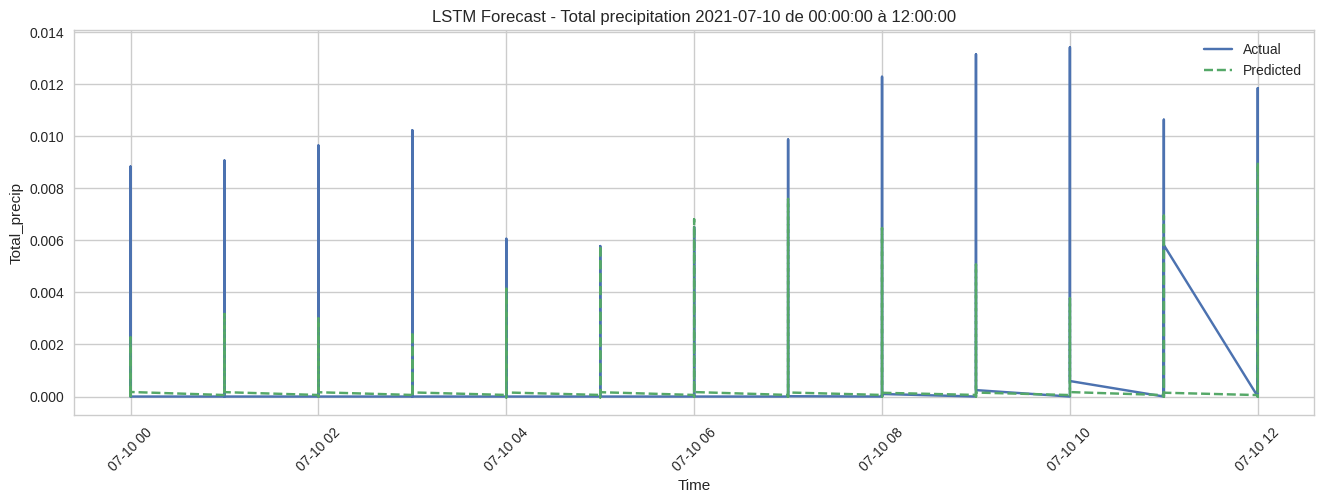

In [48]:
# Visualization
#plt.style.use('seaborn')
#plt.style.use('fivethirtyeight')
plt.style.use('seaborn-whitegrid')
#plt.style.use('ggplot')

#########################################################
range_future =10
index_test=Data_test.index
plt.figure(figsize=(16, 5))
plt.plot(Y_horaire.index, Y_horaire.Test, label='Actual')
plt.plot(Y_horaire.index, Y_horaire.Prediction, label='Predicted', linestyle='--')
plt.xlabel('Time')
plt.xticks(rotation=45)
plt.ylabel(target_variable)
plt.title('LSTM Forecast - Total precipitation 2021-07-10 de 00:00:00 à 12:00:00')
plt.legend()
plt.savefig('Forecast_lstm.png')         
plt.show()


In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score  
# 4. Evaluate the Model  
mse = mean_squared_error(y_test, y_pred)  
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)
# Results and Interpretations  
print(f'Mean Squared Error: {mse:.8f}')  
print(f' Root Mean Squared Error: {rmse:.8f}')  
print(f'Mean Absolute Error: {mse:.8f}') 
print(f'R^2 Score: {r2:.5f}') 

Mean Squared Error: 0.00061904
 Root Mean Squared Error: 0.02488047
Mean Absolute Error: 0.00061904
R^2 Score: 0.05683


In [28]:
Prediction =scaler_target.inverse_transform(y_pred)
Prediction=pd.DataFrame(Prediction ,columns =['Prediction'], index=index_test)

In [29]:
y_test = y_test.reshape(-1, 1)
Test =scaler_target.inverse_transform(y_test)
Test=pd.DataFrame(Test,columns =['Test'], index=index_test)

In [30]:
target_data=pd.concat([Test,Prediction], axis=1)
target_data

,Test,Prediction
time,,
2021-07-10 00:00:00,0.000000,0.000049
2021-07-10 00:00:00,0.000000,0.000052
2021-07-10 00:00:00,0.000000,0.000039
2021-07-10 00:00:00,0.000000,0.000050
2021-07-10 00:00:00,0.000000,0.000045
...,...,...
2021-07-20 23:00:00,0.000011,0.000137
2021-07-20 23:00:00,0.000011,0.000167
2021-07-20 23:00:00,0.000011,0.000180


In [44]:
target_data.to_csv('target_data.csv', header=True, index=True)

In [42]:
Y_horaire = target_data.loc['2021-07-10 00:00:00':'2021-07-10 12:00:00',:] 
Y_horaire

,Test,Prediction
time,,
2021-07-10 00:00:00,0.00000,0.000049
2021-07-10 00:00:00,0.00000,0.000052
2021-07-10 00:00:00,0.00000,0.000039
2021-07-10 00:00:00,0.00000,0.000050
2021-07-10 00:00:00,0.00000,0.000045
...,...,...
2021-07-10 12:00:00,0.00538,0.000168
2021-07-10 12:00:00,0.00538,0.000149
2021-07-10 12:00:00,0.00538,0.000135


/tmp/ipykernel_15385/3518720609.py:3: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


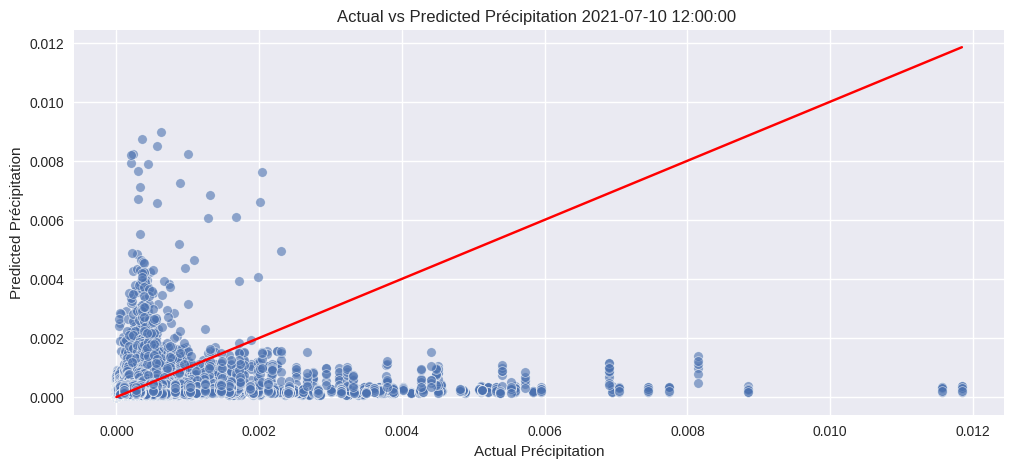

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn')

# Visualizing the regression results
plt.figure(figsize=(12,5))
sns.scatterplot(data=Y_horaire, x=Y_horaire['Test'], y=Y_horaire['Prediction'], alpha=0.6)
sns.lineplot(x=[Y_horaire['Test'].min(), 
                Y_horaire['Test'].max()], y=[Y_horaire['Test'].min(), Y_horaire['Test'].max()], color='red')
plt.title('Actual vs Predicted Précipitation 2021-07-10 12:00:00 ')
plt.xlabel('Actual Précipitation')
plt.ylabel('Predicted Précipitation')
plt.show()

##  Enhancing the Visualization

In [ ]:
# Calculating the residuals (errors)
residuals = abs(Y_horaire['Test'] - Y_horaire['Prediction'])

# Creating an enhanced scatter plot with residuals
plt.figure(figsize=(12,5))
scatter = sns.scatterplot(x=Y_horaire['Test'], y=Y_horaire['Prediction'], hue=residuals, palette='coolwarm', alpha=0.6)
sns.lineplot(x=[Y_horaire['Test'].min(), Y_horaire['Test'].max()], 
             y=[Y_horaire['Test'].min(), Y_horaire['Test'].max()], color='red')

plt.title('Actual vs Predicted Précipitation 2021-07-10 12:00:00')
plt.xlabel('Actual Précipitation')
plt.ylabel('Predicted Précipitation')
plt.savefig('Regressor_lstm.png')
plt.show()

## Sauvegarder le modéle 

In [ ]:
from keras.models import load_model
best_model.save('my_model.h5')  # creates a HDF5 file 'my_model.h5'


In [ ]:
# returns a compiled model
# identical to the previous one
from keras.models import load_model
best_model = load_model('my_model.h5')

 # Test de validation avec les données de 2021

In [10]:
## chargement de la data initiale
import pandas as pd
validation = pd.read_csv("new_df_07.csv",index_col="time", parse_dates=["time"])
validation


,level,latitude,longitude,Rel_hum,Spec_hum,U_wind,V_wind,Temp_2m,SST,Total_precip
time,,,,,,,,,,
2021-07-01 00:00:00,1000.0,17.0,-20.0,89.016754,0.012509,-0.239685,-8.683853,293.88354,295.44824,0.0
2021-07-01 00:00:00,825.0,17.0,-20.0,9.125364,0.001993,-3.615967,-0.220261,293.88354,295.44824,0.0
2021-07-01 00:00:00,700.0,17.0,-20.0,26.375015,0.003528,-8.091248,-1.598740,293.88354,295.44824,0.0
2021-07-01 00:00:00,600.0,17.0,-20.0,42.549150,0.003060,-8.525162,0.852921,293.88354,295.44824,0.0
2021-07-01 00:00:00,200.0,17.0,-20.0,37.260284,0.000031,-6.662399,5.360290,293.88354,295.44824,0.0
...,...,...,...,...,...,...,...,...,...,...
2021-07-31 23:00:00,825.0,5.0,10.0,87.003220,0.012196,3.851334,-2.277115,292.82593,0.00000,0.0
2021-07-31 23:00:00,700.0,5.0,10.0,80.080154,0.008188,-1.807358,1.199600,292.82593,0.00000,0.0
2021-07-31 23:00:00,600.0,5.0,10.0,90.847500,0.006324,-3.892456,2.275589,292.82593,0.00000,0.0


In [ ]:
# Ramener la variable time en colonne 
df=validation.reset_index()
# Find the minimum and maximum dates

min_date = df['time'].min()
max_date = df['time'].max()

print('Minimum date:', min_date)
print('Maximum date:', max_date)

In [ ]:
test_data=validation.loc['2021-07-10':'2021-07-20']

In [ ]:
test_data

In [ ]:
test_data.to_csv('test_data.csv', header=True, index=True)

In [9]:
test_data = pd.read_csv("test_data.csv",index_col="time", parse_dates=["time"])
test_data

,level,latitude,longitude,Rel_hum,Spec_hum,U_wind,V_wind,Temp_2m,SST,Total_precip
time,,,,,,,,,,
2021-07-10 00:00:00,1000.0,17.0,-20.0,90.518005,0.013498,-2.258667,-9.039429,294.61597,295.7307,0.000000
2021-07-10 00:00:00,825.0,17.0,-20.0,10.407017,0.002273,-4.478989,-8.627609,294.61597,295.7307,0.000000
2021-07-10 00:00:00,700.0,17.0,-20.0,22.393433,0.003107,-1.360123,-8.020859,294.61597,295.7307,0.000000
2021-07-10 00:00:00,600.0,17.0,-20.0,39.009003,0.003180,-1.614975,-0.939331,294.61597,295.7307,0.000000
2021-07-10 00:00:00,200.0,17.0,-20.0,15.439852,0.000015,-7.429382,4.204346,294.61597,295.7307,0.000000
...,...,...,...,...,...,...,...,...,...,...
2021-07-20 23:00:00,825.0,5.0,10.0,95.501510,0.012978,2.921631,-0.422653,293.00780,0.0000,0.000011
2021-07-20 23:00:00,700.0,5.0,10.0,83.375180,0.008439,0.748840,1.168091,293.00780,0.0000,0.000011
2021-07-20 23:00:00,600.0,5.0,10.0,94.328550,0.006477,0.250061,-1.029236,293.00780,0.0000,0.000011


In [10]:
# Normalize the data
scaler = MinMaxScaler()
scaler_target = MinMaxScaler()
scaler_data= np.concatenate([scaler.fit_transform(test_data[['longitude', 'latitude', 'Temp_2m', 'SST','level',
                                                        'Rel_hum', 'Spec_hum', 'U_wind', 'V_wind']]),
                                scaler_target.fit_transform(test_data[[target_variable]])], axis = 1)

Data_test= pd.DataFrame(scaler_data, columns =['longitude', 'latitude', 'Temp_2m', 'SST','level', 'Rel_hum', 
                                          'Spec_hum', 'U_wind', 'V_wind','Total_precip'] ,index=test_data.index)

In [11]:
# Create lag features
for feature in features:
    Data_test[feature + '_lag1'] = Data_test[feature].shift(1)
Data_test.dropna(inplace=True)

In [12]:
# Update features list
lag_features = [f + '_lag1' for f in features]
all_features = features + lag_features

In [ ]:
#Data_test.to_csv('test_lag.csv', header=True, index=True)

## Using resample() to Downsampling time series

In [ ]:
# Sampling selon par heure   voir: https://www.kaggle.com/code/dheerparikh/time-series-in-pandas
import matplotlib.pyplot as plt
plt.style.use('seaborn')
## Sample par Jour
#dataset.resample('D').mean()
# Sample par heure
validation=validation.resample('H',kind='timestap').mean()

In [ ]:
# Split test data to X and y
#X_validation = X_horaire.drop('Total_precip', axis = 1)
#y_true = X_horaire.loc[:,['Total_precip']]

In [ ]:
## Réorganiser les colonnes
#X_horaire = X_horaire.reindex(['longitude', 'latitude', 'Temp_2m', 'SST','Total_precip','level', 
                          #      'Rel_hum', 'Spec_hum', 'U_wind', 'V_wind'], axis=1)
#X_horaire

## To do 
**Faire entrer ces données dans TimeGAN**

In [ ]:
validation

In [ ]:
X_horaire = validation.loc['2021-06-01 00:00:00':'2021-06-01 12:00:00',:] 
X_horaire

In [ ]:
X_horaire.to_csv('X_horaire.csv', header=True, index=True)

In [ ]:
## chargement de l'echantillon
file = 'generated_dataset.csv'
X_generated = pd.read_csv(file, parse_dates = ['time'], index_col = 'time')
X_generated 

In [ ]:
# ordonner le dataset
X_generated = X_generated.sort_index()

In [ ]:
# Select the target variable and features
target_variable = 'Total_precip'
features = ['longitude', 'latitude', 'Temp_2m','SST','level', 
            'Rel_hum', 'Spec_hum', 'U_wind', 'V_wind']

In [ ]:
# Normalize the data
scaler = MinMaxScaler()
scaler_target = MinMaxScaler()
scaler_data= np.concatenate([scaler.fit_transform(X_generated[['longitude', 'latitude', 'Temp_2m', 'SST','level',
                                                        'Rel_hum', 'Spec_hum', 'U_wind', 'V_wind']]),
                                scaler_target.fit_transform(X_generated[[target_variable]])], axis = 1)

Data= pd.DataFrame(scaler_data, columns =['longitude', 'latitude', 'Temp_2m', 'SST','level', 'Rel_hum', 
                                          'Spec_hum', 'U_wind', 'V_wind','Total_precip'] ,index=X_generated.index)

In [ ]:
Data

In [ ]:
# Create lag features
for feature in features:
    Data[feature + '_lag1'] = Data[feature].shift(1)
Data.dropna(inplace=True)

In [ ]:
# Update features list
lag_features = [f + '_lag1' for f in features]
all_features = features + lag_features

In [ ]:
Data

In [ ]:
# Split train data to X and y
y_val = Data.loc[:,[target_variable]]
X_val = Data.drop(target_variable, axis = 1).values

In [ ]:
X_val.shape

In [ ]:
X_val = np.reshape(X_val, (X_val.shape[0], 1, X_val.shape[1]))
#X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

In [ ]:
prediction = best_model.predict(X_val)


In [ ]:
prediction.shape

In [ ]:
### Inverse scaler
Prediction =scaler_target.inverse_transform(prediction)
Prediction=pd.DataFrame(Prediction,columns =['Prediction'], index=Data.index)

In [ ]:
Prediction

In [ ]:
y_true =scaler_target.inverse_transform(y_val)
y_true=pd.DataFrame(y_true,columns =['Total_precip'], index=Data.index)

In [ ]:
target_data=X_val= pd.concat([y_true, Prediction], axis=1)
target_data

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizing the regression results
plt.figure(figsize=(12,5))
sns.scatterplot(data=target_data, x=target_data['Total_precip'], y=target_data['Prediction'], alpha=0.6)
sns.lineplot(x=[target_data['Total_precip'].min(), 
                target_data['Total_precip'].max()], y=[target_data['Total_precip'].min(), target_data['Total_precip'].max()], color='red')
plt.title('Actual vs Predicted Précipitation')
plt.xlabel('Actual Précipitation')
plt.ylabel('Predicted Précipitation')
plt.show()

##  Enhancing the Visualization

In [ ]:
# Calculating the residuals (errors)
residuals = abs(target_data['Total_precip'] - target_data['Prediction'])

# Creating an enhanced scatter plot with residuals
plt.figure(figsize=(12,5))
scatter = sns.scatterplot(x=target_data['Total_precip'], y=target_data['Prediction'], hue=residuals, palette='coolwarm', alpha=0.6)
sns.lineplot(x=[target_data['Total_precip'].min(), target_data['Total_precip'].max()], 
             y=[target_data['Total_precip'].min(), target_data['Total_precip'].max()], color='red')

plt.title('Actual vs Predicted Précipitation')
plt.xlabel('Actual Précipitation')
plt.ylabel('Predicted Précipitation')
plt.show()

##  Another Approach to Enhance the Visualization


In [ ]:
# Defining a threshold for outliers
threshold = 0.008  # You can adjust this value based on your criteria
# Calculating the residuals (errors)
residuals = abs(target_data['Total_precip'] - target_data['Prediction'])

# Plotting with outliers highlighted
plt.figure(figsize=(10,6))
sns.scatterplot(x=target_data['Total_precip'], y=target_data['Prediction'], alpha=0.6)
sns.scatterplot(x=target_data['Total_precip'][abs(residuals) > threshold], y=target_data['Prediction'][residuals > threshold], color='red', label='Outliers')
sns.lineplot(x=[target_data['Total_precip'].min(), target_data['Total_precip'].max()], y=[target_data['Total_precip'].min(), target_data['Total_precip'].max()], color='green')
plt.title('Actual vs Predicted Précipitation with Outliers Highlighted')
plt.xlabel('Actual Précipitation')
plt.ylabel('Predicted Précipitation')
plt.legend()
plt.show()

In [ ]:
# Visualization
#plt.style.use('seaborn')
#plt.style.use('fivethirtyeight')
#plt.style.use('seaborn-whitegrid')
plt.style.use('ggplot')

#########################################################
#range_future =100

plt.figure(figsize=(16, 5))
plt.plot(X_horaire.index, X_horaire['Total_precip'], label='Actual')
plt.plot(target_data.index, target_data['Prediction'], label='Predicted', linestyle='--')
plt.xlabel('Time')
plt.xticks(rotation=45)
plt.ylabel(target_variable)
plt.title('LSTM Forecast - Total precipitation')
plt.legend()
plt.savefig('lag_target')
plt.show()


In [ ]:
target_data.index